In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

plt.style.use('seaborn-v0_8')
%matplotlib inline

In [3]:
df = pd.read_csv('UK-HPI-full-file-2025-12.csv', low_memory=False)

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nFirst few rows:")
df.head()

Shape: (149085, 54)

Columns:
 ['Date', 'RegionName', 'AreaCode', 'AveragePrice', 'Index', 'IndexSA', '1m%Change', '12m%Change', 'AveragePriceSA', 'SalesVolume', 'DetachedPrice', 'DetachedIndex', 'Detached1m%Change', 'Detached12m%Change', 'SemiDetachedPrice', 'SemiDetachedIndex', 'SemiDetached1m%Change', 'SemiDetached12m%Change', 'TerracedPrice', 'TerracedIndex', 'Terraced1m%Change', 'Terraced12m%Change', 'FlatPrice', 'FlatIndex', 'Flat1m%Change', 'Flat12m%Change', 'CashPrice', 'CashIndex', 'Cash1m%Change', 'Cash12m%Change', 'CashSalesVolume', 'MortgagePrice', 'MortgageIndex', 'Mortgage1m%Change', 'Mortgage12m%Change', 'MortgageSalesVolume', 'FTBPrice', 'FTBIndex', 'FTB1m%Change', 'FTB12m%Change', 'FOOPrice', 'FOOIndex', 'FOO1m%Change', 'FOO12m%Change', 'NewPrice', 'NewIndex', 'New1m%Change', 'New12m%Change', 'NewSalesVolume', 'OldPrice', 'OldIndex', 'Old1m%Change', 'Old12m%Change', 'OldSalesVolume']

First few rows:


,Date,RegionName,AreaCode,AveragePrice,Index,IndexSA,1m%Change,12m%Change,AveragePriceSA,SalesVolume,...,NewPrice,NewIndex,New1m%Change,New12m%Change,NewSalesVolume,OldPrice,OldIndex,Old1m%Change,Old12m%Change,OldSalesVolume
0,01/01/2004,Aberdeenshire,S12000034,84638,41.1,NaN,NaN,NaN,NaN,388.0,...,112843.0,40.7,NaN,NaN,103.0,81273.0,41.0,NaN,NaN,285.0
1,01/02/2004,Aberdeenshire,S12000034,84623,41.1,NaN,0.0,NaN,NaN,326.0,...,113061.0,40.8,0.2,NaN,107.0,81194.0,40.9,-0.1,NaN,219.0
2,01/03/2004,Aberdeenshire,S12000034,86536,42.1,NaN,2.3,NaN,NaN,453.0,...,115218.0,41.6,1.9,NaN,140.0,83137.0,41.9,2.4,NaN,313.0
3,01/04/2004,Aberdeenshire,S12000034,87373,42.5,NaN,1.0,NaN,NaN,571.0,...,115247.0,41.6,0.0,NaN,180.0,84241.0,42.5,1.3,NaN,391.0
4,01/05/2004,Aberdeenshire,S12000034,89493,43.5,NaN,2.4,NaN,NaN,502.0,...,117377.0,42.4,1.8,NaN,167.0,86466.0,43.6,2.6,NaN,335.0


In [4]:
# Check the date range of the full dataset
print("Date range:", df['Date'].min(), "→", df['Date'].max())

# List every unique region so we can pick the exact spelling for filtering
print(f"\nTotal regions: {df['RegionName'].nunique()}")
print("\nAll regions:")
for r in sorted(df['RegionName'].unique()):
    print(" ", r)

Date range: 01/01/1969 → 01/12/2025

Total regions: 405

All regions:
  Aberdeenshire
  Adur
  Amber Valley
  Angus
  Antrim and Newtownabbey
  Ards and North Down
  Argyll and Bute
  Armagh City Banbridge and Craigavon
  Arun
  Ashfield
  Ashford
  Babergh
  Barking and Dagenham
  Barnet
  Barnsley
  Basildon
  Basingstoke and Deane
  Bassetlaw
  Bath and North East Somerset
  Bedford
  Belfast
  Bexley
  Birmingham
  Blaby
  Blackburn with Darwen
  Blackpool
  Blaenau Gwent
  Bolsover
  Bolton
  Boston
  Bournemouth Christchurch and Poole
  Bracknell Forest
  Bradford
  Braintree
  Breckland
  Brent
  Brentwood
  Bridgend
  Brighton and Hove
  Broadland
  Bromley
  Bromsgrove
  Broxbourne
  Broxtowe
  Buckinghamshire
  Burnley
  Bury
  Caerphilly
  Calderdale
  Cambridge
  Cambridgeshire
  Camden
  Cannock Chase
  Canterbury
  Cardiff
  Carmarthenshire
  Castle Point
  Causeway Coast and Glens
  Central Bedfordshire
  Ceredigion
  Charnwood
  Chelmsford
  Cheltenham
  Cherwell
  Ches

In [5]:
# Filter to the regional aggregate for Yorkshire
# We use the top-level region rather than individual councils (Leeds, Sheffield etc.)
region = 'Yorkshire and The Humber'
yorks = df[df['RegionName'] == region].copy()

# Parse dates — ONS uses DD/MM/YYYY format so we must specify this explicitly
yorks['Date'] = pd.to_datetime(yorks['Date'], format='%d/%m/%Y')
yorks = yorks.sort_values('Date').reset_index(drop=True)

# Keep only the columns we need for now
# AveragePrice is our target variable, SalesVolume gives us transaction activity
yorks = yorks[['Date', 'AveragePrice', 'SalesVolume']]

print(f"Rows: {len(yorks)}")
print(f"Date range: {yorks['Date'].min().date()} → {yorks['Date'].max().date()}")
print(f"\nMissing values:")
print(yorks.isnull().sum())
print(f"\nSample:")
yorks.head()

Rows: 693
Date range: 1968-04-01 → 2025-12-01

Missing values:
Date              0
AveragePrice      0
SalesVolume     323
dtype: int64

Sample:


,Date,AveragePrice,SalesVolume
0,1968-04-01,2553,NaN
1,1968-05-01,2553,NaN
2,1968-06-01,2553,NaN
3,1968-07-01,2581,NaN
4,1968-08-01,2581,NaN


In [6]:
# Pre-1995 ONS data is less reliable — methodology changed significantly
# Trimming to 1995 onwards gives us 30 years of consistent data
yorks = yorks[yorks['Date'] >= '1995-01-01'].reset_index(drop=True)

# SalesVolume has too many early gaps to be useful as a feature
# We'll keep it for plotting context but won't use it in the model
yorks = yorks.drop(columns=['SalesVolume'])

print(f"Rows after trim: {len(yorks)}")
print(f"Date range: {yorks['Date'].min().date()} → {yorks['Date'].max().date()}")
print(f"\nMissing values:")
print(yorks.isnull().sum())
yorks.head()

Rows after trim: 372
Date range: 1995-01-01 → 2025-12-01

Missing values:
Date            0
AveragePrice    0
dtype: int64


,Date,AveragePrice
0,1995-01-01,42171
1,1995-02-01,41912
2,1995-03-01,42544
3,1995-04-01,42934
4,1995-05-01,42197


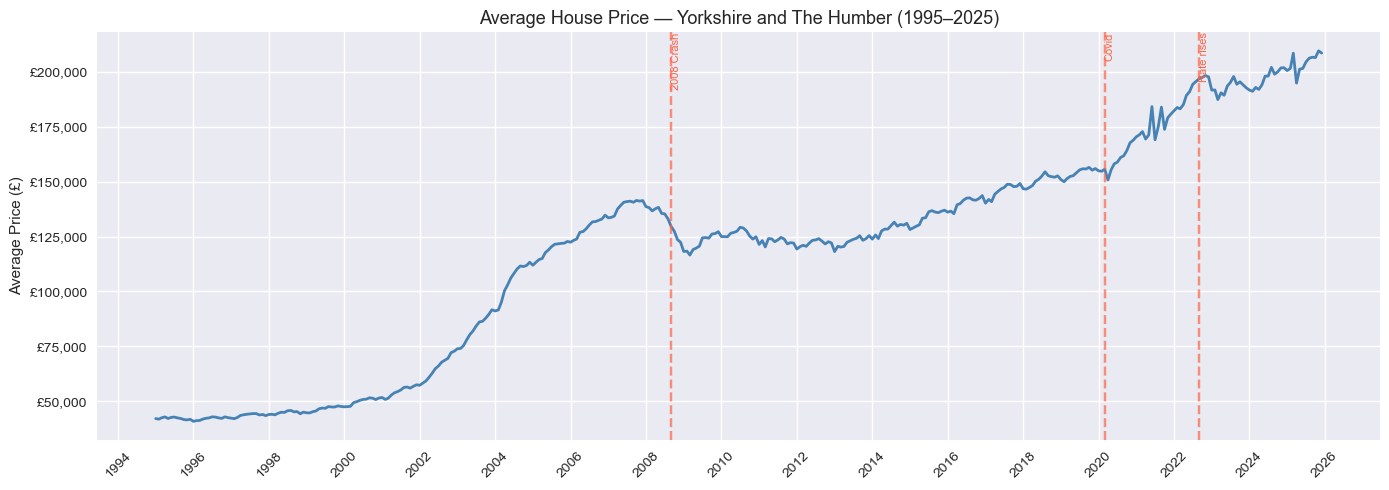

In [7]:
# Plot the full price history for Yorkshire
# This is the most important chart — shows trend, crashes, and recovery periods
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(yorks['Date'], yorks['AveragePrice'], linewidth=2, color='steelblue')

# Mark key events so we can see how they show up in the data
events = {
    '2008-09-01': '2008 Crash',
    '2020-03-01': 'Covid',
    '2022-09-01': 'Rate rises'
}
for date, label in events.items():
    ax.axvline(pd.Timestamp(date), color='tomato', linestyle='--', alpha=0.7)
    ax.text(pd.Timestamp(date), ax.get_ylim()[1], label, 
            rotation=90, fontsize=8, color='tomato', va='top')

ax.set_title('Average House Price — Yorkshire and The Humber (1995–2025)', fontsize=13)
ax.set_ylabel('Average Price (£)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

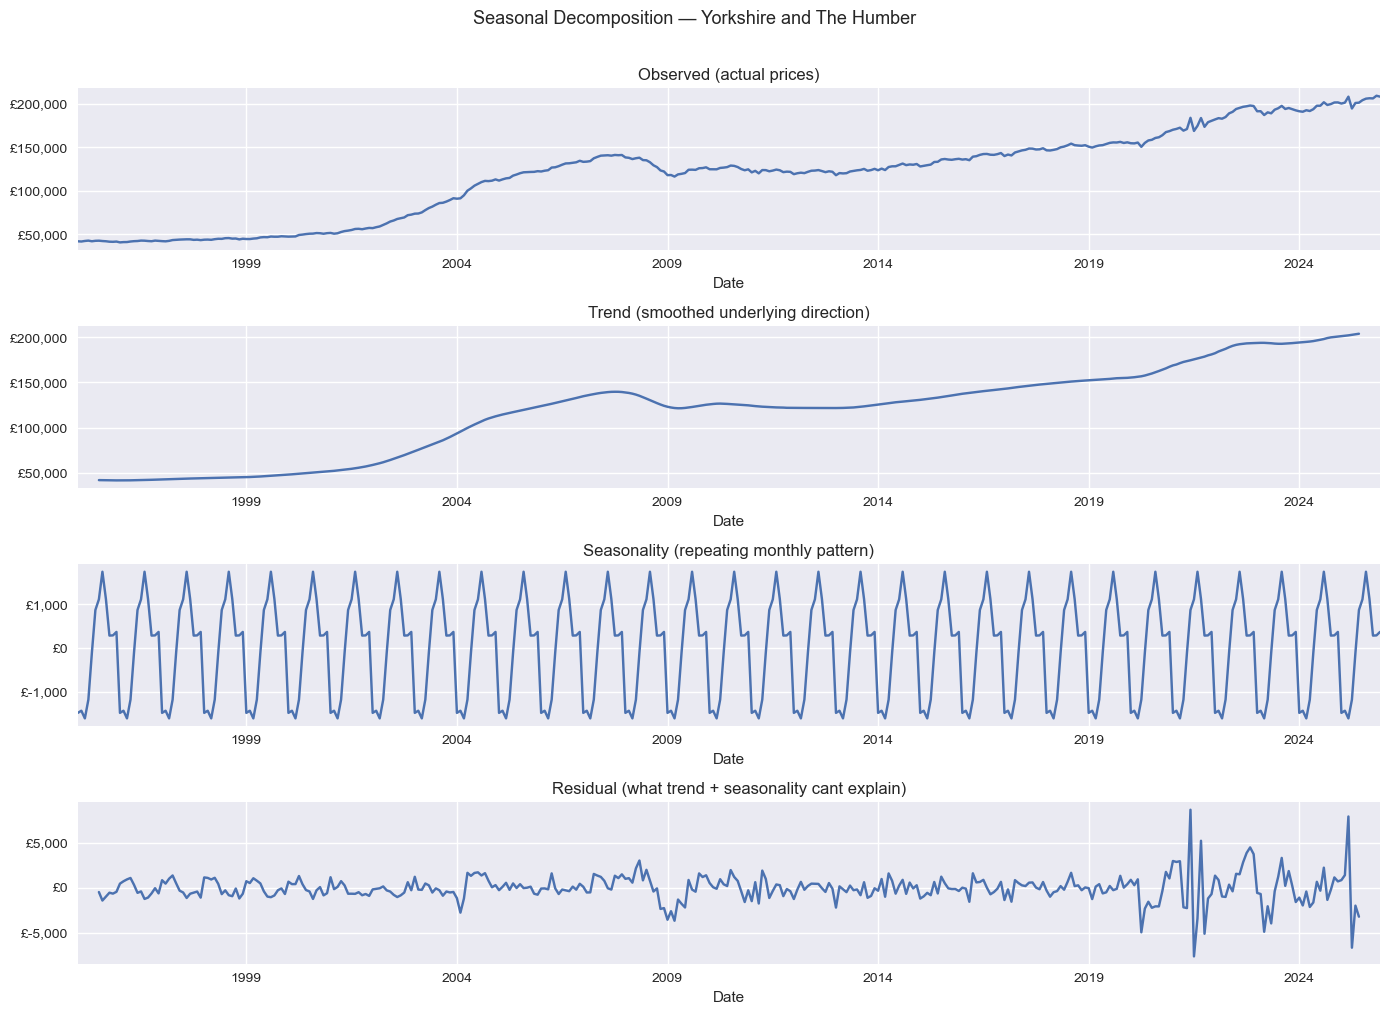

In [8]:
# Decompose the series into trend, seasonality, and residual components
# This tells us whether there's a repeating monthly pattern the model needs to learn
# period=12 because we have monthly data and expect annual seasonality
ts = yorks.set_index('Date')['AveragePrice']

decomp = seasonal_decompose(ts, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))

decomp.observed.plot(ax=axes[0], title='Observed (actual prices)')
decomp.trend.plot(ax=axes[1], title='Trend (smoothed underlying direction)')
decomp.seasonal.plot(ax=axes[2], title='Seasonality (repeating monthly pattern)')
decomp.resid.plot(ax=axes[3], title='Residual (what trend + seasonality cant explain)')

for ax in axes:
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

plt.suptitle('Seasonal Decomposition — Yorkshire and The Humber', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [9]:
# Augmented Dickey-Fuller test — checks whether the series has a unit root
# A non-stationary series (p > 0.05) means prices are trending and don't revert to a mean
# This is expected for house prices and tells us we need lag features rather than ARIMA differencing
result = adfuller(ts.dropna())

print("ADF Statistic:", round(result[0], 4))
print("p-value:      ", round(result[1], 4))
print("\nCritical values:")
for key, val in result[4].items():
    print(f"  {key}: {round(val, 4)}")

print("\nInterpretation:")
if result[1] < 0.05:
    print("✅ Stationary — series has no persistent trend")
else:
    print("⚠️  Non-stationary — series has a persistent trend (expected for house prices)")
    print("   This means we'll use lag features rather than raw price levels in the model")

ADF Statistic: -0.4187
p-value:       0.9069

Critical values:
  1%: -3.4489
  5%: -2.8697
  10%: -2.5711

Interpretation:
⚠️  Non-stationary — series has a persistent trend (expected for house prices)
   This means we'll use lag features rather than raw price levels in the model
